In [2]:
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Rescaling
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt

# 1. CONFIGURACIÓN DE RUTAS Y PARÁMETROS
# Apuntamos a la carpeta procesada local que generaste en el paso anterior
PROJECT_ROOT = os.path.dirname(os.path.abspath(os.path.join(os.getcwd())))
PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data/processed/")

TRAIN_DIR = os.path.join(PROCESSED_DIR, "train")
VAL_DIR = os.path.join(PROCESSED_DIR, "val")
TEST_DIR = os.path.join(PROCESSED_DIR, "test")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("[INFO] Cargando pipelines de datos...")

# 2. CREACIÓN DE PIPELINES DE DATOS EFICIENTES (tf.data)
# Usamos image_dataset_from_directory, que es el estándar moderno en Keras 3 / TF 2.x
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary', # 0 para Normal, 1 para Neumonía
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False
)

# Optimizaciones de memoria para Mac / entornos locales
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

[INFO] Cargando pipelines de datos...
Found 5340 files belonging to 2 classes.
Found 1628 files belonging to 2 classes.
Found 1642 files belonging to 2 classes.


In [3]:
# 3. DEFINICIÓN DE LA ARQUITECTURA (MODELO BASELINE)
model = Sequential([
    # Capa de entrada y normalización de píxeles [0, 255] -> [0.0, 1.0]
    Rescaling(1./255, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    
    # Bloque Convolucional 1
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    # Bloque Convolucional 2
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    # Bloque Convolucional 3
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    # Capa de Aplanado (Flatten)
    Flatten(),
    
    # Capa Densa Intermedia con Regularización Dropout
    Dense(128, activation='relu'),
    Dropout(0.5), # Apaga el 50% de las neuronas aleatoriamente en cada iteración
    
    # Capa de Salida para Clasificación Binaria
    Dense(1, activation='sigmoid')
])

# 4. COMPILACIÓN DEL MODELO
# Usamos BinaryCrossentropy por ser un problema binario y Adam como optimizador estándar
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall')] 
    # Monitoreamos Recall explícitamente por exigencia del dominio médico
)

model.summary()

# 5. CALLBACKS ACADÉMICOS: GUARDADO Y PARADA TEMPRANA
os.makedirs("../models", exist_ok=True)
checkpoint_path = "../models/baseline_cnn.h5"

callbacks = [
    # Detiene el entrenamiento si la pérdida de validación deja de mejorar por 5 épocas
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    # Guarda únicamente los pesos del modelo que obtengan el mejor rendimiento en validación
    ModelCheckpoint(filepath=checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1)
]

# 6. ENTRENAMIENTO DEL MODELO
EPOCHS = 20 # Definimos 20, pero EarlyStopping puede terminarlo antes si converge
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

/Users/juan/miniconda3/envs/ml-env/lib/python3.12/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

...


Epoch 13: finished saving model to ../models/baseline_cnn.h5
167/167 ━━━━━━━━━━━━━━━━━━━━ 778s 5s/step - accuracy: 0.9682 - loss: 0.0910 - recall: 0.9820 - val_accuracy: 0.9748 - val_loss: 0.0688 - val_recall: 0.9823
Epoch 14/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 0.9727 - loss: 0.0722 - recall: 0.9823
Epoch 14: val_loss improved from 0.06882 to 0.06693, saving model to ../models/baseline_cnn.h5



Epoch 14: finished saving model to ../models/baseline_cnn.h5
167/167 ━━━━━━━━━━━━━━━━━━━━ 67s 402ms/step - accuracy: 0.9702 - loss: 0.0780 - recall: 0.9831 - val_accuracy: 0.9748 - val_loss: 0.0669 - val_recall: 0.9865
Epoch 15/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.9684 - loss: 0.0782 - recall: 0.9816
Epoch 15: val_loss did not improve from 0.06693
167/167 ━━━━━━━━━━━━━━━━━━━━ 68s 408ms/step - accuracy: 0.9665 - loss: 0.0829 - recall: 0.9808 - val_accuracy: 0.9754 - val_loss: 0.0674 - val_recall: 0.9848
Epoch 16/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.9742 - loss: 0.0675 - recall: 0.9853
Epoch 16: val_loss did not improve from 0.06693
167/167 ━━━━━━━━━━━━━━━━━━━━ 75s 446ms/step - accuracy: 0.9719 - loss: 0.0714 - recall: 0.9838 - val_accuracy: 0.9730 - val_loss: 0.0686 - val_recall: 0.9924
Epoch 17/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.9738 - loss: 0.0687 - recall: 0.9868
Epoch 17: val_loss improved from 0.06693 to 0.0637


Epoch 17: finished saving model to ../models/baseline_cnn.h5
167/167 ━━━━━━━━━━━━━━━━━━━━ 78s 464ms/step - accuracy: 0.9749 - loss: 0.0662 - recall: 0.9867 - val_accuracy: 0.9748 - val_loss: 0.0637 - val_recall: 0.9916
Epoch 18/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step - accuracy: 0.9723 - loss: 0.0668 - recall: 0.9850
Epoch 18: val_loss improved from 0.06372 to 0.05769, saving model to ../models/baseline_cnn.h5



Epoch 18: finished saving model to ../models/baseline_cnn.h5
167/167 ━━━━━━━━━━━━━━━━━━━━ 77s 462ms/step - accuracy: 0.9747 - loss: 0.0659 - recall: 0.9864 - val_accuracy: 0.9785 - val_loss: 0.0577 - val_recall: 0.9924
Epoch 19/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.9781 - loss: 0.0525 - recall: 0.9892
Epoch 19: val_loss improved from 0.05769 to 0.05408, saving model to ../models/baseline_cnn.h5



Epoch 19: finished saving model to ../models/baseline_cnn.h5
167/167 ━━━━━━━━━━━━━━━━━━━━ 79s 470ms/step - accuracy: 0.9785 - loss: 0.0544 - recall: 0.9887 - val_accuracy: 0.9828 - val_loss: 0.0541 - val_recall: 0.9874
Epoch 20/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.9809 - loss: 0.0480 - recall: 0.9896
Epoch 20: val_loss did not improve from 0.05408
167/167 ━━━━━━━━━━━━━━━━━━━━ 80s 478ms/step - accuracy: 0.9800 - loss: 0.0508 - recall: 0.9905 - val_accuracy: 0.9791 - val_loss: 0.0550 - val_recall: 0.9857
Restoring model weights from the end of the best epoch: 19.



--- Evaluando en el conjunto de prueba (Test) ---
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - accuracy: 0.9817 - loss: 0.0542 - recall: 0.9850
Test Loss: 0.0542
Test Accuracy: 0.9817
Test Recall: 0.9850


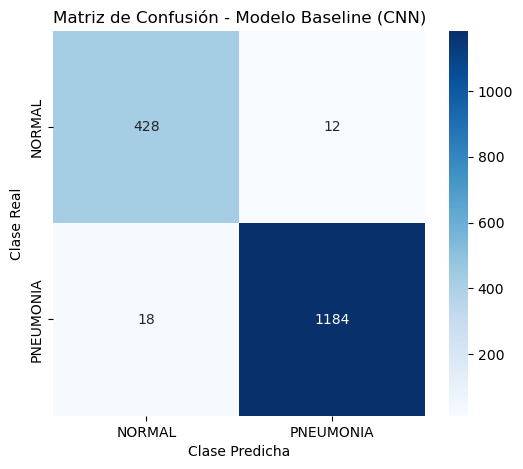


--- Reporte de Clasificación ---
              precision    recall  f1-score   support

      NORMAL       0.96      0.97      0.97       440
   PNEUMONIA       0.99      0.99      0.99      1202

    accuracy                           0.98      1642
   macro avg       0.97      0.98      0.98      1642
weighted avg       0.98      0.98      0.98      1642



In [4]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 1. EVALUACIÓN FINAL EN EL CONJUNTO DE PRUEBA (TEST)
print("\n--- Evaluando en el conjunto de prueba (Test) ---")
test_loss, test_acc, test_recall = model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Recall: {test_recall:.4f}")

# 2. GENERACIÓN DE PREDICCIONES PARA MATRIZ DE CONFUSIÓN
y_true = []
y_pred = []

# Extraer etiquetas reales y predecir
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy().flatten())
    y_pred.extend((preds.flatten() > 0.5).astype(int))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# 3. VISUALIZACIÓN DE LA MATRIZ DE CONFUSIÓN
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['NORMAL', 'PNEUMONIA'], 
            yticklabels=['NORMAL', 'PNEUMONIA'])
plt.title('Matriz de Confusión - Modelo Baseline (CNN)')
plt.ylabel('Clase Real')
plt.xlabel('Clase Predicha')
plt.show()

# 4. REPORTE DE CLASIFICACIÓN DETALLADO
print("\n--- Reporte de Clasificación ---")
print(classification_report(y_true, y_pred, target_names=['NORMAL', 'PNEUMONIA']))